## How are in-demand skills trending for Data Analysts?

### Methodology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [1]:
# Import Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_MX = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'Mexico')].copy()

In [3]:
df_DA_MX['job_posted_month_no'] = df_DA_MX['job_posted_date'].dt.month

In [4]:
df_DA_MX_explode = df_DA_MX.explode('job_skills')

In [10]:
df_DA_MX_pivot = df_DA_MX_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_MX_pivot.loc['Total'] = df_DA_MX_pivot.sum()

df_DA_MX_pivot = df_DA_MX_pivot[df_DA_MX_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_MX_pivot = df_DA_MX_pivot.drop('Total')

df_DA_MX_pivot

job_skills,sql,python,excel,power bi,tableau,r,aws,sap,sas,sql server,...,chef,seaborn,sqlserver,debian,digitalocean,kafka,jenkins,smartsheet,graphql,docker
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,29,24,19,16,17,11,3,6,2,4,...,0,0,0,1,0,0,0,0,0,0
2,5,8,4,3,4,2,1,1,8,2,...,0,0,0,0,0,1,0,0,0,0
3,18,16,9,10,10,10,1,0,2,1,...,0,0,0,0,0,0,0,0,0,0
4,15,10,12,7,6,5,4,2,0,3,...,0,0,0,0,0,0,1,0,1,0
5,19,15,11,6,10,10,7,4,2,1,...,0,0,0,0,0,0,0,1,0,0
6,34,15,16,18,13,5,4,5,4,4,...,0,0,1,0,1,0,0,0,0,0
7,35,20,25,17,14,10,5,3,10,3,...,0,0,0,0,0,0,0,0,0,0
8,48,34,28,23,26,18,11,11,4,6,...,0,0,0,0,0,0,0,0,0,0
9,30,19,14,16,13,10,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


In [12]:
DA_totals = df_DA_MX.groupby('job_posted_month_no').size()

In [20]:
df_DA_MX_percent = df_DA_MX_pivot.div(DA_totals/100, axis=0)

df_DA_MX_percent

job_skills,sql,python,excel,power bi,tableau,r,aws,sap,sas,sql server,...,chef,seaborn,sqlserver,debian,digitalocean,kafka,jenkins,smartsheet,graphql,docker
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,46.774194,38.709677,30.645161,25.806452,27.419355,17.741935,4.838710,9.677419,3.225806,6.451613,...,0.000000,0.000000,0.000000,1.612903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,23.809524,38.095238,19.047619,14.285714,19.047619,9.523810,4.761905,4.761905,38.095238,9.523810,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.761905,0.000000,0.000000,0.000000,0.000000
3,51.428571,45.714286,25.714286,28.571429,28.571429,28.571429,2.857143,0.000000,5.714286,2.857143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,48.387097,32.258065,38.709677,22.580645,19.354839,16.129032,12.903226,6.451613,0.000000,9.677419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.225806,0.000000,3.225806,0.000000
5,82.608696,65.217391,47.826087,26.086957,43.478261,43.478261,30.434783,17.391304,8.695652,4.347826,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.347826,0.000000,0.000000
6,64.150943,28.301887,30.188679,33.962264,24.528302,9.433962,7.547170,9.433962,7.547170,7.547170,...,0.000000,0.000000,1.886792,0.000000,1.886792,0.000000,0.000000,0.000000,0.000000,0.000000
7,56.451613,32.258065,40.322581,27.419355,22.580645,16.129032,8.064516,4.838710,16.129032,4.838710,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,64.000000,45.333333,37.333333,30.666667,34.666667,24.000000,14.666667,14.666667,5.333333,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,56.603774,35.849057,26.415094,30.188679,24.528302,18.867925,5.660377,1.886792,7.547170,7.547170,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [21]:
# Changing month number to month name
df_DA_MX_percent = df_DA_MX_percent.reset_index()
df_DA_MX_percent['job_posted_month'] = df_DA_MX_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_MX_percent = df_DA_MX_percent.set_index('job_posted_month')
df_DA_MX_percent = df_DA_MX_percent.drop(columns='job_posted_month_no')

df_DA_MX_percent

job_skills,sql,python,excel,power bi,tableau,r,aws,sap,sas,sql server,...,chef,seaborn,sqlserver,debian,digitalocean,kafka,jenkins,smartsheet,graphql,docker
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,46.774194,38.709677,30.645161,25.806452,27.419355,17.741935,4.838710,9.677419,3.225806,6.451613,...,0.000000,0.000000,0.000000,1.612903,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,23.809524,38.095238,19.047619,14.285714,19.047619,9.523810,4.761905,4.761905,38.095238,9.523810,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.761905,0.000000,0.000000,0.000000,0.000000
Mar,51.428571,45.714286,25.714286,28.571429,28.571429,28.571429,2.857143,0.000000,5.714286,2.857143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,48.387097,32.258065,38.709677,22.580645,19.354839,16.129032,12.903226,6.451613,0.000000,9.677419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.225806,0.000000,3.225806,0.000000
May,82.608696,65.217391,47.826087,26.086957,43.478261,43.478261,30.434783,17.391304,8.695652,4.347826,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.347826,0.000000,0.000000
Jun,64.150943,28.301887,30.188679,33.962264,24.528302,9.433962,7.547170,9.433962,7.547170,7.547170,...,0.000000,0.000000,1.886792,0.000000,1.886792,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,56.451613,32.258065,40.322581,27.419355,22.580645,16.129032,8.064516,4.838710,16.129032,4.838710,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,64.000000,45.333333,37.333333,30.666667,34.666667,24.000000,14.666667,14.666667,5.333333,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,56.603774,35.849057,26.415094,30.188679,24.528302,18.867925,5.660377,1.886792,7.547170,7.547170,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


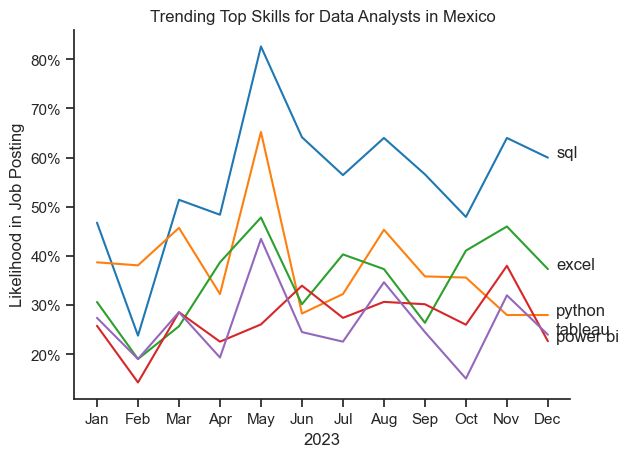

In [40]:
df_plot = df_DA_MX_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in Mexico')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter())

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])